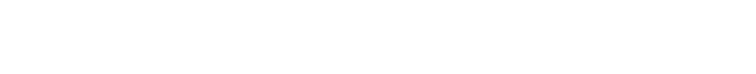
Documentacion: https://gymnasium.farama.org/environments/toy_text/blackjack/


In [6]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict

env = gym.make("Blackjack-v1", sab=False)  # sab=False: modo estándar

# Explorar el espacio
print(
    "Obs space:", env.observation_space
)  # Tuple(Discrete(32),Discrete(11),Discrete(2))
print("Act space:", env.action_space)  # Discrete(2)  → 0=STAND, 1=HIT

# Primer episodio
obs, _ = env.reset()
print(f"Estado inicial: suma={obs[0]}, dealer={obs[1]}, as={obs[2]}")
obs, r, done, _, _ = env.step(1)  # HIT
print(f"Tras HIT: suma={obs[0]}, r={r}, done={done}")

Obs space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Act space: Discrete(2)
Estado inicial: suma=18, dealer=10, as=0
Tras HIT: suma=19, r=0.0, done=False


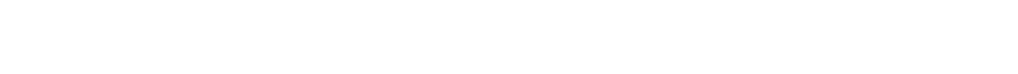


In [8]:
# def simple_policy(obs):
#     """Política fija: HIT si suma_jugador ≤ 18, STAND en otro caso."""
#     player_sum, dealer_card, usable_ace = obs
#     return 1 if player_sum <= 18 else 0  # 1=HIT, 0=STAND


def simple_policy(obs):
    return 0


def generate_episode(env, policy):
    """
    Genera un episodio completo.
    Retorna lista de (state, action, reward).
    """
    episode = []
    obs, _ = env.reset()
    while True:
        action = policy(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        episode.append((obs, action, reward))
        obs = next_obs
        if terminated or truncated:
            break
    return episode


# Probar con 5 episodios
for ep_num in range(5):
    ep = generate_episode(env, simple_policy)
    final_r = ep[-1][2]
    print(
        f"Episodio {ep_num+1}: {len(ep)} pasos, reward={final_r:+.0f}, "
        f"último estado={ep[-1][0]}"
    )

Episodio 1: 1 pasos, reward=-1, último estado=(13, 2, 0)
Episodio 2: 1 pasos, reward=-1, último estado=(19, 5, 0)
Episodio 3: 1 pasos, reward=-1, último estado=(14, 10, 0)
Episodio 4: 1 pasos, reward=-1, último estado=(10, 10, 0)
Episodio 5: 1 pasos, reward=+1, último estado=(21, 10, 1)


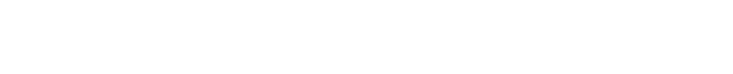


In [9]:
def mc_prediction_first_visit(env, policy, n_episodes=500_000, gamma=1.0):
    """
    MC Prediction (first-visit) para estimar V(s).
    Retorna V: dict {state: float}
    """
    returns_sum = defaultdict(float)  # Σ retornos por estado
    returns_count = defaultdict(int)  # N visitas por estado
    V = defaultdict(float)

    for ep in range(n_episodes):
        episode = generate_episode(env, policy)

        # ── Recorrido inverso para calcular G eficientemente ──
        G = 0
        visited_states = set()  # para first-visit
        for state, action, reward in reversed(episode):
            G = gamma * G + reward
            if state not in visited_states:  # first-visit check
                visited_states.add(state)
                returns_sum[state] += G
                returns_count[state] += 1
                V[state] = returns_sum[state] / returns_count[state]

        if (ep + 1) % 100_000 == 0:
            print(f"  Episodio {ep+1:>7d} | Estados visitados: {len(V)}")

    return V


print("Ejecutando MC Prediction (500K episodios)...")
V_pi = mc_prediction_first_visit(env, simple_policy, n_episodes=500_000)
print(f"Total estados estimados: {len(V_pi)}")

Ejecutando MC Prediction (500K episodios)...
  Episodio  100000 | Estados visitados: 270
  Episodio  200000 | Estados visitados: 270
  Episodio  300000 | Estados visitados: 270
  Episodio  400000 | Estados visitados: 270
  Episodio  500000 | Estados visitados: 270
Total estados estimados: 270


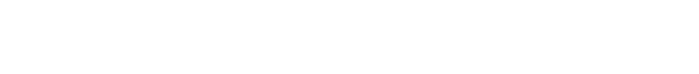


In [10]:
# ── Inspeccionar algunos estados específicos ──────────────────
test_states = [
    (21, 3, True),  # suma=21, dealer muestra 3, tiene as → casi ganar seguro
    (11, 3, False),  # suma=11, dealer muestra 3 → HIT es bueno
    (20, 8, False),  # suma=20, dealer muestra 8 → STAND probablemente
    (12, 2, False),  # suma=12, dealer muestra 2 → caso difícil
]
print(f"{'Estado':>25}  {'V(s)':>8}  {'Interpretación'}")
print("-" * 65)
for s in test_states:
    v = V_pi.get(s, float("nan"))
    interp = (
        "Casi seguro ganar"
        if v > 0.5
        else ("Casi empate" if abs(v) < 0.1 else "Probable perder")
    )
    print(f"  {str(s):>23}  {v:>8.4f}  {interp}")

# ── Distribución de valores ────────────────────────────────────
all_values = list(V_pi.values())
print(
    f"\nV(s) medio: {np.mean(all_values):.4f}  (esperado negativo: π simple pierde más)"
)
print(f"V(s) mín:   {np.min(all_values):.4f}")
print(f"V(s) máx:   {np.max(all_values):.4f}")

                   Estado      V(s)  Interpretación
-----------------------------------------------------------------
            (21, 3, True)    0.8906  Casi seguro ganar
           (11, 3, False)   -0.2239  Probable perder
           (20, 8, False)    0.7843  Casi seguro ganar
           (12, 2, False)   -0.2817  Probable perder

V(s) medio: -0.1704  (esperado negativo: π simple pierde más)
V(s) mín:   -0.8051
V(s) máx:   0.9433


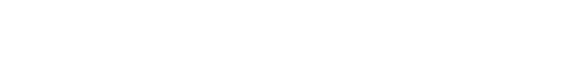


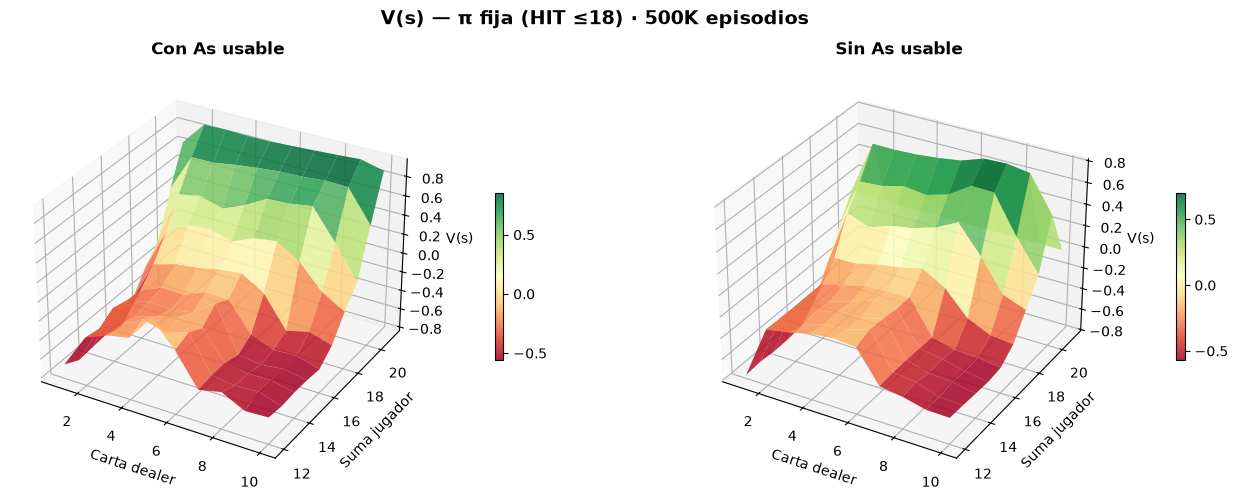

In [11]:
def plot_value_function_3d(V, title="MC Prediction — V(s)"):
    """Superficie 3D de V(s) sobre suma_jugador × carta_dealer."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={"projection": "3d"})

    for ax, usable_ace, subtitle in zip(
        axes, [True, False], ["Con As usable", "Sin As usable"]
    ):
        player_sums = np.arange(12, 22)  # 12-21
        dealer_cards = np.arange(1, 11)  # 1-10
        X, Y = np.meshgrid(dealer_cards, player_sums)
        Z = np.array(
            [
                [V.get((ps, dc, usable_ace), 0) for dc in dealer_cards]
                for ps in player_sums
            ]
        )

        surf = ax.plot_surface(
            X, Y, Z, cmap="RdYlGn", linewidth=0, antialiased=True, alpha=0.85
        )
        ax.set_xlabel("Carta dealer", fontsize=10)
        ax.set_ylabel("Suma jugador", fontsize=10)
        ax.set_zlabel("V(s)", fontsize=10)
        ax.set_title(subtitle, fontsize=12, fontweight="bold", pad=10)
        fig.colorbar(surf, ax=ax, shrink=0.4, pad=0.1)

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_value_function_3d(V_pi, "V(s) — π fija (HIT ≤18) · 500K episodios")

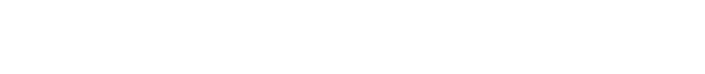


  Episodio  100000 | Estados visitados: 270
  Episodio  100000 | Estados visitados: 270
  Episodio  200000 | Estados visitados: 270
  Episodio  300000 | Estados visitados: 270
  Episodio  400000 | Estados visitados: 270
  Episodio  500000 | Estados visitados: 270
Convergencia de V(20, 3, False):
     1000 episodios → V = 0.7500
    10000 episodios → V = 0.5949
   100000 episodios → V = 0.6535
   500000 episodios → V = 0.6500


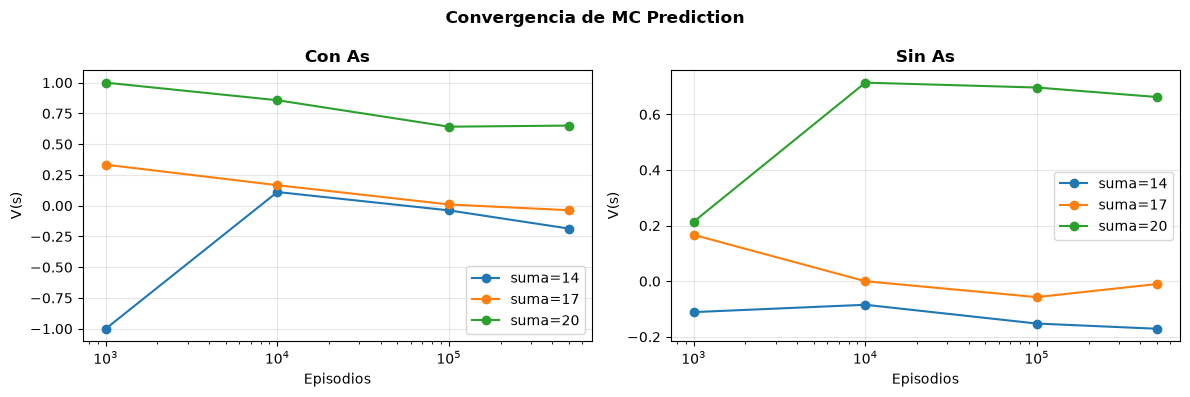

In [12]:
# Ejecutar con distintos números de episodios y comparar V(s)
n_episodes_list = [1_000, 10_000, 100_000, 500_000]
Vs = {}

for n in n_episodes_list:
    Vs[n] = mc_prediction_first_visit(env, simple_policy, n_episodes=n, gamma=1.0)

# Estado de referencia para seguir convergencia
ref_state = (20, 3, False)
print(f"Convergencia de V{ref_state}:")
for n, V_n in Vs.items():
    v = V_n.get(ref_state, float("nan"))
    print(f"  {n:>7} episodios → V = {v:.4f}")

# Graficar convergencia
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
states_track = [(12, 3, True), (16, 7, False), (20, 3, False), (21, 6, True)]
for ax, ua, title in zip(axes, [True, False], ["Con As", "Sin As"]):
    for ps in [14, 17, 20]:
        vals = [Vs[n].get((ps, 5, ua), float("nan")) for n in n_episodes_list]
        ax.semilogx(n_episodes_list, vals, "o-", label=f"suma={ps}")
    ax.set_title(title, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlabel("Episodios")
    ax.set_ylabel("V(s)")
plt.suptitle("Convergencia de MC Prediction", fontweight="bold")
plt.tight_layout()
plt.show()

## T4. Respuestas de análisis

**Q1.** Un as usable puede contarse como 11 sin que la mano exceda 21. Esto da un margen de seguridad: al pedir una carta, si la suma supera 21, el as puede pasar a valer 1 y evita el bust. Por eso, para la misma suma observada y la misma carta del dealer, `V(s)` suele ser mayor con as usable que sin él.

**Q2.** Con suma 21 el jugador hace `STAND`, pero no gana con probabilidad 1. El dealer todavía puede terminar con 21, en cuyo caso el resultado es empate y la recompensa es 0. Por tanto, el retorno esperado combina victorias (+1) y empates (0), de modo que queda por debajo de +1; una estimación cercana a +0.9 es razonable.

**Q3.** Si la política fuera `π = siempre STAND`, el jugador conservaría su suma actual. Con sumas bajas (12--16), `V(s)` normalmente seguiría siendo negativo: si el dealer no se pasa, terminará al menos en 17 y vencerá al jugador. Sin embargo, esos valores serán relativamente mayores contra cartas bajas del dealer (2--6), porque el dealer debe pedir más cartas para llegar a 17 y aumenta su probabilidad de bust; contra un 9, 10 o as visible, esa probabilidad es menor y `V(s)` será más bajo. Para 19, 20 y 21 no habría cambio respecto a la política actual, ya que esta ya hace `STAND` en esos estados.

**Q4.** `Vπ(12, 2, False) ≈ -0.3` responde: "si estoy en este estado y continúo siguiendo la política fija `π` (HIT hasta 18), ¿cuál es mi retorno medio?". Que sea negativo no responde por sí solo si ahora conviene `HIT` o `STAND`, porque `Vπ(s)` mezcla la acción elegida por `π` y todas las decisiones posteriores. Para decidir entre acciones se necesitan dos valores: `Q(s, HIT)`, el retorno medio si primero se pide carta, y `Q(s, STAND)`, el retorno medio si primero se planta. Desde 12, pedir tiene riesgo de bust si sale una carta de valor 10, pero plantarse también es malo porque el dealer normalmente alcanzará al menos 17. En este estado, MC Control suele aprender que `HIT` tiene el mayor valor esperado. Con first-visit MC, en cada episodio se actualiza una sola vez cada par `(s, a)`: se promedia el retorno observado tras su primera aparición. La exploración ε-greedy permite probar ambas acciones y, al final, se selecciona `argmax Q[s]`.


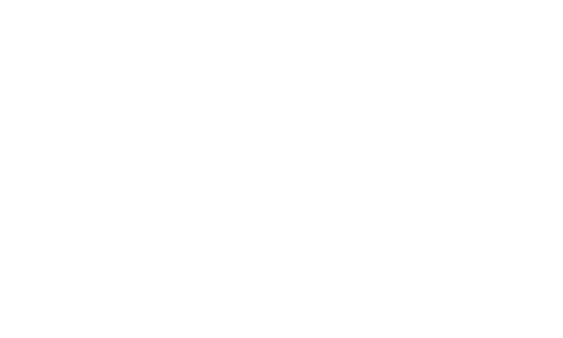


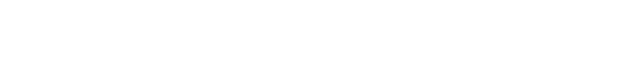


In [ ]:
def mc_control(env, n_episodes=500_000, gamma=1.0, epsilon=0.1):
    """MC Control on-policy con first-visit MC y política ε-greedy."""
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    reward_history = []  # para graficar convergencia

    def epsilon_greedy(state, eps):
        # Con prob. ε → acción aleatoria
        if np.random.rand() < eps:
            return env.action_space.sample()
        # Con prob. 1-ε → argmax Q[state] (la mejor acción conocida)
        else:
            return int(np.argmax(Q[state]))

    for ep in range(n_episodes):
        # 1. Generar episodio siguiendo la política epsilon_greedy
        episode = []
        state, _ = env.reset()
        done = False

        while not done:
            action = epsilon_greedy(state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            if terminated or truncated:
                done = True

        # 2. Recorrido inverso, first-visit, actualizar Q y mejorar π
        G = 0
        visited = set()

        # Iteramos el episodio de fin a inicio
        for state, action, reward in reversed(episode):
            # Calculamos el retorno acumulado G
            G = gamma * G + reward

            # Verificamos First-Visit: solo tomamos en cuenta la primera vez
            # que se vio este par estado-acción en el episodio
            if (state, action) not in visited:
                visited.add((state, action))

                # Sumamos el retorno y contamos cuántas veces hemos visto el par
                returns_sum[(state, action)] += G
                returns_count[(state, action)] += 1

                # Actualizamos el valor Q con el promedio empírico
                Q[state][action] = (
                    returns_sum[(state, action)] / returns_count[(state, action)]
                )

        # Guardamos el reward del paso final para monitorear convergencia
        reward_history.append(episode[-1][2] if episode else 0)

    # Extraer política greedy final (la que maximiza Q sin exploración epsilon)
    policy = {s: np.argmax(Q[s]) for s in Q}
    return Q, policy, reward_history

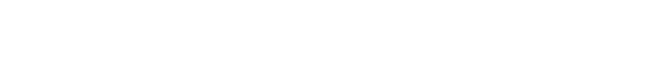


Entrenando con ε=0.1...
Entrenando con ε=0.3...
Entrenando con ε=0.5...


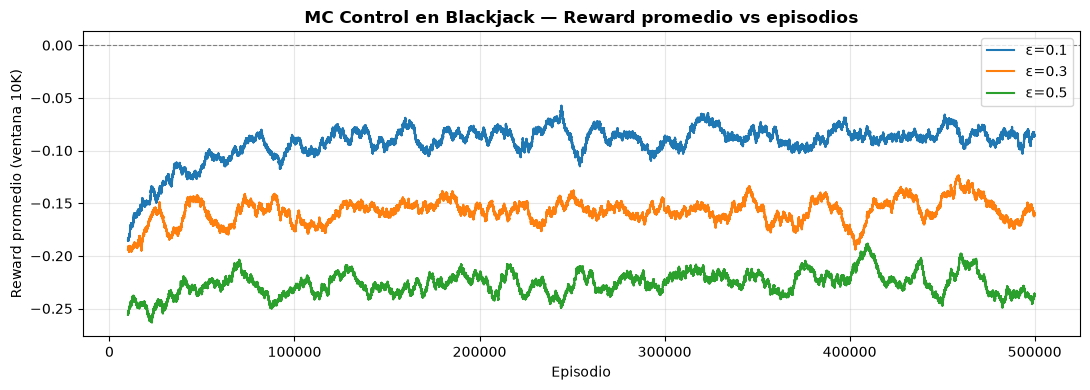

In [8]:
epsilons = [0.1, 0.3, 0.5]
results = {}

for eps in epsilons:
    print(f"Entrenando con ε={eps}...")
    Q_e, policy_e, rewards_e = mc_control(
        env, n_episodes=500_000, gamma=1.0, epsilon=eps
    )
    results[eps] = {"Q": Q_e, "policy": policy_e, "rewards": rewards_e}

# ── Graficar reward promedio móvil ─────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
window = 10_000

for eps, res in results.items():
    r = np.array(res["rewards"])
    # Media móvil con ventana de 10K episodios
    ma = np.convolve(r, np.ones(window) / window, mode="valid")
    ax.plot(range(window - 1, len(r)), ma, linewidth=1.5, label=f"ε={eps}")

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title(
    "MC Control en Blackjack — Reward promedio vs episodios",
    fontweight="bold",
    fontsize=12,
)
ax.set_xlabel("Episodio")
ax.set_ylabel("Reward promedio (ventana 10K)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

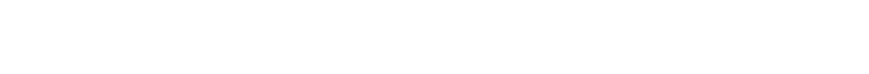


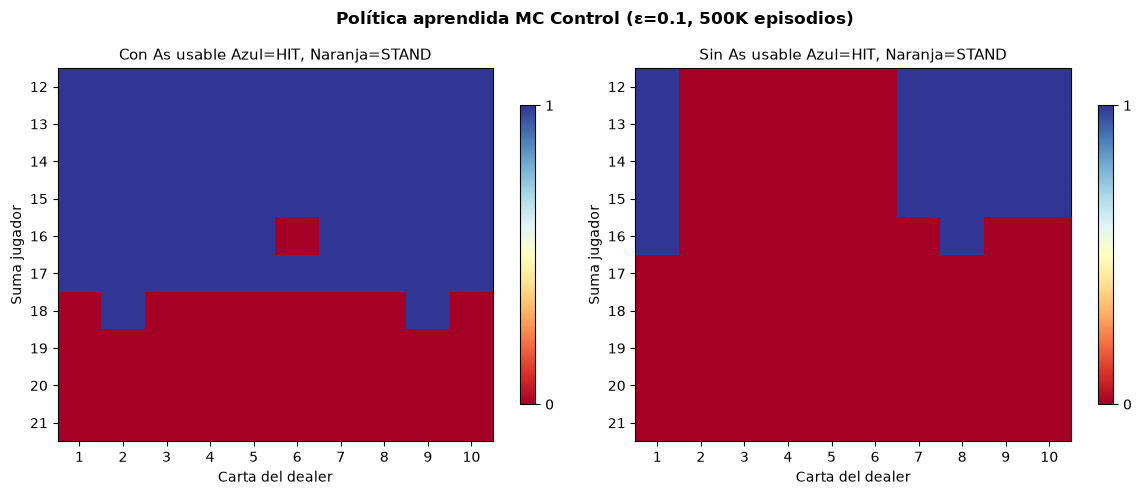

In [9]:
def plot_policy(policy, title="Política aprendida"):
    """Tabla de π*(s): 1=HIT (azul), 0=STAND (naranja)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, usable_ace, subtitle in zip(
        axes, [True, False], ["Con As usable", "Sin As usable"]
    ):
        player_sums = list(range(12, 22))
        dealer_cards = list(range(1, 11))
        grid = np.array(
            [
                [policy.get((ps, dc, usable_ace), 0) for dc in dealer_cards]
                for ps in player_sums
            ]
        )

        im = ax.imshow(
            grid, cmap="RdYlBu", vmin=0, vmax=1, aspect="auto", origin="upper"
        )
        ax.set_xticks(range(10))
        ax.set_xticklabels(dealer_cards)
        ax.set_yticks(range(10))
        ax.set_yticklabels(player_sums)
        ax.set_xlabel("Carta del dealer")
        ax.set_ylabel("Suma jugador")
        ax.set_title(f"{subtitle} Azul=HIT, Naranja=STAND", fontsize=11)
        plt.colorbar(im, ax=ax, ticks=[0, 1], shrink=0.8)

    fig.suptitle(title, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


best_eps = min(epsilons)  # toma el ε más pequeño
plot_policy(
    results[best_eps]["policy"],
    f"Política aprendida MC Control (ε={best_eps}, 500K episodios)",
)

In [10]:
# ── C4: exploración decreciente ──
# ε_t = max(0.01, 1.0 * 0.9999^t)
def epsilon_schedule(ep, eps_start=1.0, eps_min=0.01, decay=0.9999):
    return max(eps_min, eps_start * (decay**ep))


# Modifica mc_control() para que acepte
# eps_schedule como función
# y compara con ε=0.1 fijo en reward

**Dilema Exploración-Explotación: ¿Por qué ε decreciente generalmente supera a ε fijo a largo plazo? Conéctalo con el dilema exploración-explotación.**

>

**Estrategia Aprendida vs. Real: Tu política aprendida, ¿coincide con la estrategia básica real? ¿En qué estados difiere más? ¿A qué se debe?**

>

**Con 500K episodios y ε=0.1, ¿la política converge al óptimo? ¿Cómo verificarías que no estás atrapado?**

>


Entrenando con ε fijo (0.1)...
Entrenando con ε decreciente...


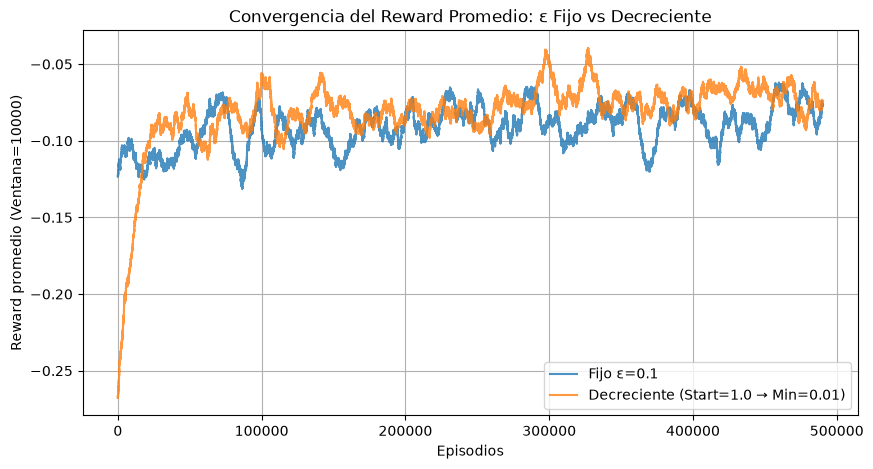

In [ ]:
import matplotlib.pyplot as plt


# ── C4: exploración decreciente ──
# ε_t = max(0.01, 1.0 * 0.9999^t)
def epsilon_schedule(ep, eps_start=1.0, eps_min=0.01, decay=0.9999):
    return max(eps_min, eps_start * (decay**ep))


# Modificación de mc_control() para aceptar eps_schedule
def mc_control_adaptive(
    env, n_episodes=500_000, gamma=1.0, epsilon=0.1, eps_schedule=None
):
    """MC Control on-policy. Soporta tanto ε fijo como una función de ε decreciente."""
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    reward_history = []

    def epsilon_greedy(state, eps):
        if np.random.rand() < eps:
            return env.action_space.sample()
        else:
            return int(np.argmax(Q[state]))

    for ep in range(n_episodes):
        # Seleccionamos el ε: Si enviamos función, evaluamos la función en base al episodio.
        # Caso contrario, utilizamos el epsilon fijo.
        current_eps = eps_schedule(ep) if eps_schedule is not None else epsilon

        # Generar episodio
        episode = []
        state, _ = env.reset()
        done = False
        while not done:
            action = epsilon_greedy(state, current_eps)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            if terminated or truncated:
                done = True

        # Recorrido inverso, actualización Q
        G = 0
        visited = set()
        for state, action, reward in reversed(episode):
            G = gamma * G + reward
            if (state, action) not in visited:
                visited.add((state, action))
                returns_sum[(state, action)] += G
                returns_count[(state, action)] += 1
                Q[state][action] = (
                    returns_sum[(state, action)] / returns_count[(state, action)]
                )

        reward_history.append(episode[-1][2] if episode else 0)

    policy = {s: np.argmax(Q[s]) for s in Q}
    return Q, policy, reward_history


# ── Entrenar y Comparar: ε=0.1 fijo vs Decreciente ──
print("Entrenando con ε fijo (0.1)...")
_, _, rewards_fixed = mc_control_adaptive(env, n_episodes=500_000, epsilon=0.1)

print("Entrenando con ε decreciente...")
_, _, rewards_decay = mc_control_adaptive(
    env, n_episodes=500_000, eps_schedule=epsilon_schedule
)

# Suavizamos los resultados usando un promedio móvil (moving average)
window = 10_000
smooth_fixed = np.convolve(rewards_fixed, np.ones(window) / window, mode="valid")
smooth_decay = np.convolve(rewards_decay, np.ones(window) / window, mode="valid")

# Graficamos la comparación
plt.figure(figsize=(10, 5))
plt.plot(smooth_fixed, label="Fijo ε=0.1", alpha=0.8)
plt.plot(smooth_decay, label="Decreciente (Start=1.0 → Min=0.01)", alpha=0.8)
plt.title("Convergencia del Reward Promedio: ε Fijo vs Decreciente")
plt.xlabel("Episodios")
plt.ylabel(f"Reward promedio (Ventana={window})")
plt.legend()
plt.grid(True)
plt.show()